# BERT trained with Few-NERD dataset

# Train your own BERT model

## Import libraries

In [ ]:
%pip install datasets evaluate
%pip install transformers[torch]
%pip install accelerate
%pip install seqeval

In [47]:
from pathlib import Path
from datasets import load_dataset
from transformers import (
    BertTokenizerFast,
    BertForTokenClassification,
    TrainingArguments,
    Trainer,
    DataCollatorForTokenClassification,
    EarlyStoppingCallback
)
import numpy as np
import evaluate
import matplotlib.pyplot as plt

## Prepare dataset and model

In [3]:
encoder_id = "bert-base-cased"
# Use the fast tokenizer version, which supports word_ids()
tokenizer = BertTokenizerFast.from_pretrained(encoder_id)

In [70]:
def tokenize_and_align_labels(examples):
    # Use padding='max_length' to ensure consistent sequence lengths
    tokenized_inputs = tokenizer(
        examples["tokens"],
        padding="max_length",
        truncation=True,
        max_length=256,  # model_max_length from original hyperparameters
        is_split_into_words=True,
    )
    
    labels_aligned = []
    for i, label in enumerate(examples["ner_tags"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        previous_word_idx = None
        label_ids = []
        for word_idx in word_ids:
            if word_idx is None:
                label_ids.append(-100)
            elif word_idx != previous_word_idx:
                label_ids.append(label[word_idx])
            else:
                label_ids.append(-100)
            previous_word_idx = word_idx
        labels_aligned.append(label_ids)
    
    tokenized_inputs["labels"] = labels_aligned
    return tokenized_inputs        


# Load dataset and adjust columns
dataset_id = "DFKI-SLT/few-nerd"
dataset_name = "FewNERD"
dataset = load_dataset(dataset_id, "supervised")
dataset = dataset.remove_columns("ner_tags")
dataset = dataset.rename_column("fine_ner_tags", "ner_tags")
labels = dataset["train"].features["ner_tags"].feature.names

# Initialize model for token classification with BERT.
model = BertForTokenClassification.from_pretrained(encoder_id, num_labels=len(labels))

# Tokenize the datasets using the custom function.
tokenized_datasets = dataset.map(tokenize_and_align_labels, batched=True)

Some weights of BertForTokenClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## Train model

In [73]:
# Prepare training arguments.
model_id = f"bert-token-classification-{encoder_id}-fewnerd-fine-super"
output_dir = Path("models") / model_id
training_args = TrainingArguments(
    output_dir=output_dir,
    learning_rate=5e-5,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    num_train_epochs=10,
    weight_decay=0.01,
    warmup_ratio=0.1,
    bf16=True,
    logging_first_step=True,
    logging_steps=50,
    eval_strategy="steps",
    save_strategy="steps",
    eval_steps=2000,  # Keep eval_steps as 3000
    save_steps=2000,  # Change save_steps to 3000 or another multiple of eval_steps
    save_total_limit=2,
    dataloader_num_workers=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_f1",
    greater_is_better=True,
)

# Load evaluation metric.
metric = evaluate.load("seqeval")

def compute_metrics(p):
    predictions, labels_batch = p
    predictions = np.argmax(predictions, axis=2)
    
    true_predictions = [
        [labels[pred] for pred, label in zip(prediction, label_seq) if label != -100]
        for prediction, label_seq in zip(predictions, labels_batch)
    ]
    true_labels = [
        [labels[label] for pred, label in zip(prediction, label_seq) if label != -100]
        for prediction, label_seq in zip(predictions, labels_batch)
    ]
    results = metric.compute(predictions=true_predictions, references=true_labels)
    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "eval_f1": results["overall_f1"],  # key for evaluation F1
        "accuracy": results["overall_accuracy"],
    }


In [74]:
# Use a dedicated data collator to handle padding of both inputs and labels.
data_collator = DataCollatorForTokenClassification(tokenizer)

# Initialize Trainer and add the early stopping callback.
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],  # Stops if no improvement in 3 eval calls.
)

# Train the model.
trainer.train()

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Step,Training Loss,Validation Loss,F1,Precision,Recall,Accuracy
2000,0.164100,0.264880,0.669003,0.651811,0.687126,0.926190
4000,0.217500,0.248847,0.673725,0.652665,0.696190,0.926535
6000,0.156800,0.266315,0.677827,0.658117,0.698753,0.926878
8000,0.115300,0.286435,0.683176,0.668091,0.698958,0.927999
10000,0.088300,0.314964,0.683239,0.669038,0.698056,0.927325
12000,0.064500,0.343139,0.686687,0.671621,0.702444,0.928316
14000,0.050000,0.356877,0.683089,0.668789,0.698015,0.927826
16000,0.039700,0.382775,0.684465,0.668367,0.701358,0.928113
18000,0.030100,0.401247,0.684362,0.666965,0.702691,0.927964


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
/home/student/miniconda3/lib

TrainOutput(global_step=18000, training_loss=0.10069901171657775, metrics={'train_runtime': 4590.4888, 'train_samples_per_second': 287.044, 'train_steps_per_second': 4.485, 'total_flos': 1.505859667266724e+17, 'train_loss': 0.10069901171657775, 'epoch': 8.742107819329771})

## Evaluate model

In [31]:
# Evaluate on test set and save metrics.
test_metrics = trainer.evaluate(tokenized_datasets["test"], metric_key_prefix="test")
trainer.save_metrics("test", test_metrics)

# Save final model checkpoint.
trainer.save_model(output_dir / "checkpoint-final")

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
/home/student/miniconda3/lib/python3.12/site-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: building-other seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/home/student/miniconda3/lib/python3.12/site-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: building-hotel seems not to be NE t

## Plotting Training and Evaluation Metrics

In [75]:
import json
print(json.dumps(trainer.state.log_history, indent=2))


[
  {
    "loss": 0.1886,
    "grad_norm": 1.1191582679748535,
    "learning_rate": 2.4283632831471588e-08,
    "epoch": 0.00048567265662943174,
    "step": 1
  },
  {
    "loss": 0.2308,
    "grad_norm": 1.0583827495574951,
    "learning_rate": 1.2141816415735795e-06,
    "epoch": 0.02428363283147159,
    "step": 50
  },
  {
    "loss": 0.2204,
    "grad_norm": 0.8698633313179016,
    "learning_rate": 2.428363283147159e-06,
    "epoch": 0.04856726566294318,
    "step": 100
  },
  {
    "loss": 0.2235,
    "grad_norm": 0.9096173048019409,
    "learning_rate": 3.642544924720739e-06,
    "epoch": 0.07285089849441477,
    "step": 150
  },
  {
    "loss": 0.2162,
    "grad_norm": 0.7610445022583008,
    "learning_rate": 4.856726566294318e-06,
    "epoch": 0.09713453132588636,
    "step": 200
  },
  {
    "loss": 0.2074,
    "grad_norm": 0.8859550952911377,
    "learning_rate": 6.0709082078678975e-06,
    "epoch": 0.12141816415735794,
    "step": 250
  },
  {
    "loss": 0.2188,
    "grad_n

9
9
9
9
9


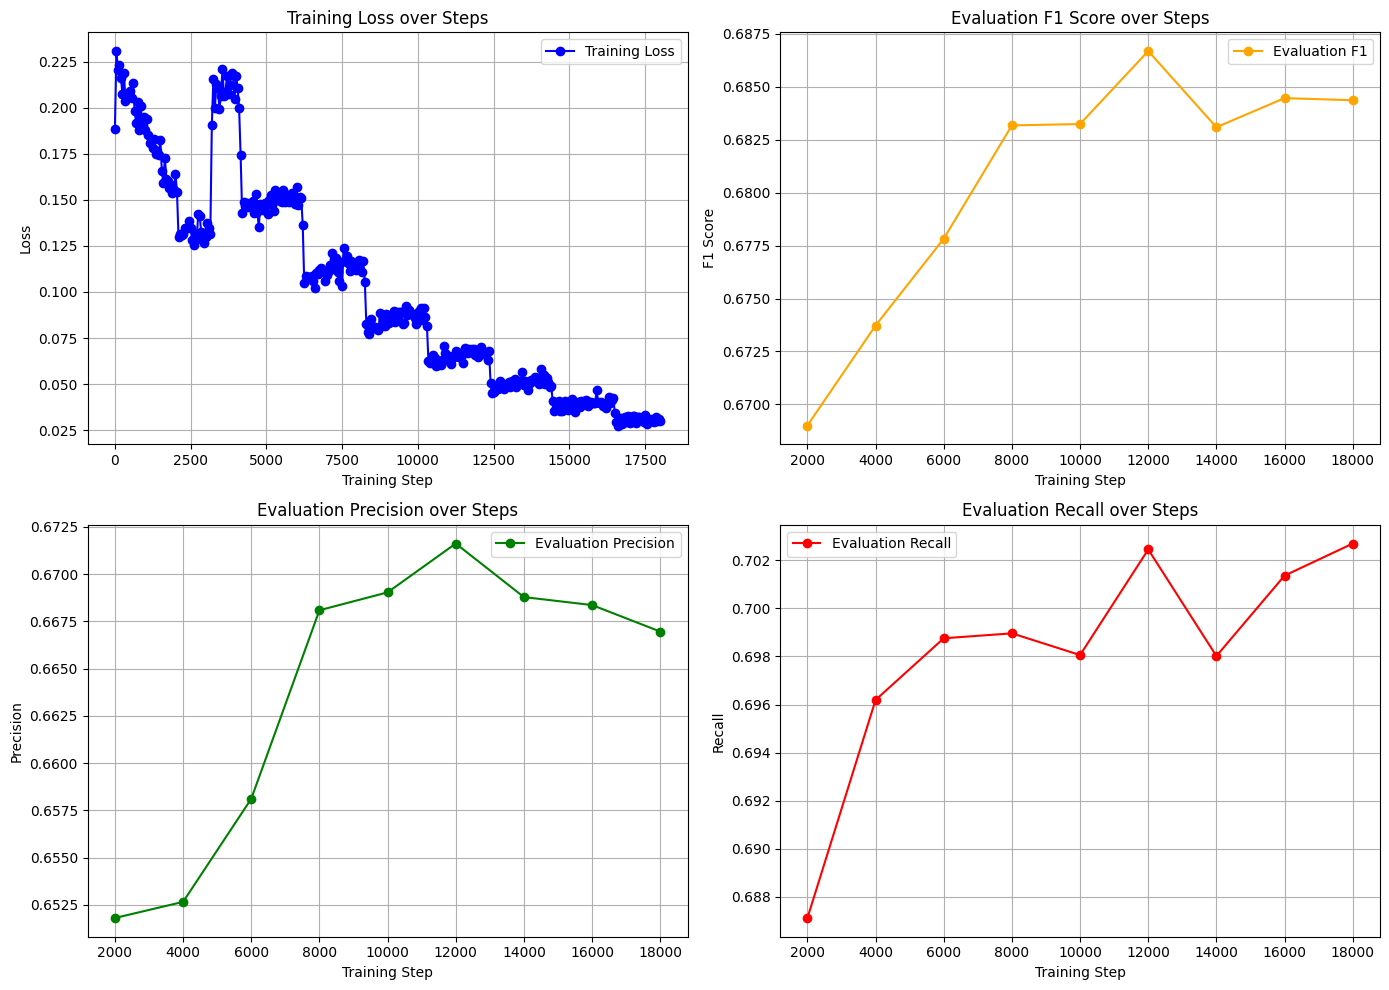

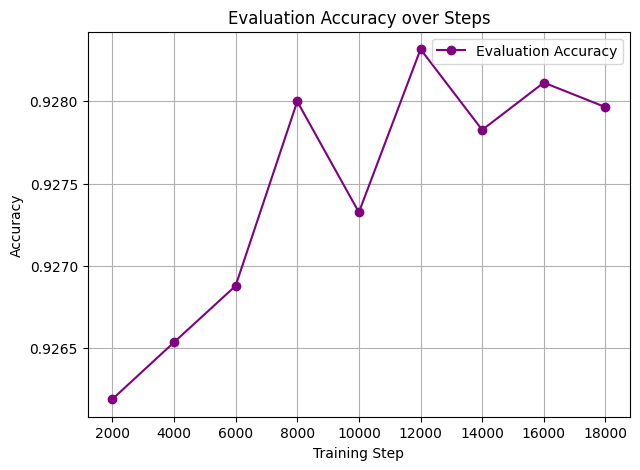

In [76]:
# The Trainer stores log history in trainer.state.log_history.
logs = trainer.state.log_history

# Extract training metrics.
train_steps = [log["step"] for log in logs if "loss" in log]
train_loss = [log["loss"] for log in logs if "loss" in log]

# Extract evaluation metrics.
eval_steps = [log["step"] for log in logs if "eval_f1" in log]
eval_f1 = [log["eval_f1"] for log in logs if "eval_f1" in log]
eval_precision = [log["eval_precision"] for log in logs if "eval_precision" in log]
eval_recall = [log["eval_recall"] for log in logs if "eval_recall" in log]
eval_accuracy = [log["eval_accuracy"] for log in logs if "eval_accuracy" in log]

print(len(eval_steps))
print(len(eval_f1))
print(len(eval_precision))
print(len(eval_recall))
print(len(eval_accuracy))


# Create subplots for training loss and evaluation metrics.
plt.figure(figsize=(14, 10))

# Training Loss Plot
plt.subplot(2, 2, 1)
plt.plot(train_steps, train_loss, marker="o", label="Training Loss", color="blue")
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("Training Loss over Steps")
plt.legend()
plt.grid(True)

# Evaluation F1 Score Plot
plt.subplot(2, 2, 2)
plt.plot(eval_steps, eval_f1, marker="o", label="Evaluation F1", color="orange")
plt.xlabel("Training Step")
plt.ylabel("F1 Score")
plt.title("Evaluation F1 Score over Steps")
plt.legend()
plt.grid(True)

# Evaluation Precision Plot
plt.subplot(2, 2, 3)
plt.plot(eval_steps, eval_precision, marker="o", label="Evaluation Precision", color="green")
plt.xlabel("Training Step")
plt.ylabel("Precision")
plt.title("Evaluation Precision over Steps")
plt.legend()
plt.grid(True)

# Evaluation Recall Plot
plt.subplot(2, 2, 4)
plt.plot(eval_steps, eval_recall, marker="o", label="Evaluation Recall", color="red")
plt.xlabel("Training Step")
plt.ylabel("Recall")
plt.title("Evaluation Recall over Steps")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Additional Accuracy Plot
plt.figure(figsize=(7, 5))
plt.plot(eval_steps, eval_accuracy, marker="o", label="Evaluation Accuracy", color="purple")
plt.xlabel("Training Step")
plt.ylabel("Accuracy")
plt.title("Evaluation Accuracy over Steps")
plt.legend()
plt.grid(True)
plt.show()


## Saving and Loading the Model

In [10]:
model_name = "weights_longer.pth"
# Save the entire model (including configuration and tokenizer state if desired)
trainer.save_model(model_name)


In [11]:
from transformers import BertForTokenClassification, BertTokenizerFast

# Load the saved model and tokenizer
model = BertForTokenClassification.from_pretrained(model_name)
tokenizer = BertTokenizerFast.from_pretrained("bert-base-cased")


## Making Predictions with Probabilities for Each Named Entity

In [20]:
import torch
import torch.nn.functional as F

# Sample text to predict on
sample_text = "John Doe visited New York City last week."

# Tokenize the sample text.
# Here, we split the text into words and use is_split_into_words=True to help with alignment.
words = sample_text.split()
inputs = tokenizer(
    words,
    is_split_into_words=True,
    return_tensors="pt",
    padding=True,
    truncation=True,
    max_length=256
)

# Forward pass through the model
with torch.no_grad():
    outputs = model(**inputs)
logits = outputs.logits  # Shape: (batch_size, seq_len, num_labels)

# Convert logits to probabilities using softmax
probs = F.softmax(logits, dim=-1)  # Shape: (batch_size, seq_len, num_labels)
predictions = torch.argmax(probs, dim=-1)  # Predicted label indices

# Get the mapping of tokens to words (word_ids)
word_ids = inputs.word_ids(batch_index=0)

# Initialize a dictionary to hold entity predictions and their top probabilities.
# We assume that tokens with a label other than "O" represent named entities.
results = {}

# Iterate over the token indices and group by word.
# Only consider the first token of a word (i.e. when word_ids change)
for idx, word_id in enumerate(word_ids):
    if word_id is None:
        continue
    # Check if this token is the first sub-token of a word.
    if idx == 0 or word_ids[idx] != word_ids[idx - 1]:
        # Get the probabilities for this token as a list
        token_probs = probs[0][idx].tolist()
        # Compute top 3 class probabilities (index, score)
        top3 = sorted(enumerate(token_probs), key=lambda x: x[1], reverse=True)[:3]
        # Map indices to label names and format the results.
        top3_labels = [(model.config.id2label[i], score) for i, score in top3]
        # If the predicted label is not the "O" (outside) label, store the entity.
        pred_label = model.config.id2label[predictions[0][idx].item()]
        if pred_label != "O":
            # Use the original word from the input list (note: words[word_id] gives a close approximation)
            results[words[word_id]] = top3_labels

print("Named Entity Predictions with Top 3 Probabilities:")
for entity, top_probs in results.items():
    print(f"Entity: {entity}")
    for label, prob in top_probs:
        print(f"  {label}: {prob:.4f}")


Named Entity Predictions with Top 3 Probabilities:
Entity: John
  LABEL_54: 0.6789
  LABEL_51: 0.1337
  LABEL_0: 0.1313
Entity: Doe
  LABEL_54: 0.6782
  LABEL_51: 0.1546
  LABEL_0: 0.1033
Entity: visited
  LABEL_0: 0.9999
  LABEL_54: 0.0000
  LABEL_21: 0.0000
Entity: New
  LABEL_21: 0.9937
  LABEL_0: 0.0033
  LABEL_25: 0.0009
Entity: York
  LABEL_21: 0.9943
  LABEL_0: 0.0032
  LABEL_25: 0.0007
Entity: City
  LABEL_21: 0.9081
  LABEL_0: 0.0877
  LABEL_25: 0.0011
Entity: last
  LABEL_0: 0.9999
  LABEL_21: 0.0000
  LABEL_25: 0.0000
Entity: week.
  LABEL_0: 1.0000
  LABEL_21: 0.0000
  LABEL_54: 0.0000


In [19]:
import torch
import torch.nn.functional as F
from transformers import BertTokenizerFast, BertForTokenClassification

# Assume the model and tokenizer have been saved and then loaded as shown:
model_path = "weights.pth"  # Change this to your saved model path
model = BertForTokenClassification.from_pretrained(model_path)
tokenizer = BertTokenizerFast.from_pretrained("bert-base-cased")

# Sample text for inference
sample_text = "John Doe visited New York City last week."

# Tokenize the full text with offsets. (Do NOT split manually to preserve original character offsets.)
encoded = tokenizer(
    sample_text,
    return_offsets_mapping=True,
    padding="max_length",
    truncation=True,
    max_length=256,
    return_tensors="pt"
)
offset_mapping = encoded.pop("offset_mapping")  # shape: (1, seq_len, 2)

# Forward pass
with torch.no_grad():
    outputs = model(**encoded)
logits = outputs.logits  # shape: (1, seq_len, num_labels)
probs = F.softmax(logits, dim=-1)  # shape: (1, seq_len, num_labels)
predictions = torch.argmax(probs, dim=-1)  # shape: (1, seq_len)

# Now, group contiguous tokens with non-"O" predictions to form entities.
# We use the offset mapping to compute the character-level boundaries.
entities = []
current_entity = None

# Get the sequence length from the offsets.
seq_len = offset_mapping.size(1)

# Iterate over tokens (index i)
for i in range(seq_len):
    # Get the offset for token i.
    start_i, end_i = offset_mapping[0, i].tolist()
    # Skip special tokens or padding (offsets of (0, 0))
    if start_i == end_i == 0:
        continue

    label_id = predictions[0, i].item()
    # If the top predicted label is "O", then this token is not part of a named entity.
    if label_id == 0:
        # If we are in the middle of an entity, finish it.
        if current_entity is not None:
            entities.append(current_entity)
            current_entity = None
        continue

    # Otherwise, token is part of an entity.
    # Get the probability distribution for this token.
    token_probs = probs[0, i]  # tensor shape: (num_labels,)
    
    # If not currently grouping an entity, start one.
    if current_entity is None:
        current_entity = {
            "start": start_i,
            "end": end_i,
            "token_indices": [i],
            "prob_sum": token_probs.clone()  # accumulate probabilities (tensor)
        }
    else:
        # Check if token i is contiguous with the previous token in the entity.
        # We consider tokens contiguous if the current token’s start is at most 1 character after the previous token’s end.
        prev_end = current_entity["end"]
        if start_i - prev_end <= 1:
            # Extend the current entity.
            current_entity["end"] = end_i
            current_entity["token_indices"].append(i)
            current_entity["prob_sum"] += token_probs
        else:
            # Finish the current entity and start a new one.
            entities.append(current_entity)
            current_entity = {
                "start": start_i,
                "end": end_i,
                "token_indices": [i],
                "prob_sum": token_probs.clone()
            }

# Append any remaining entity.
if current_entity is not None:
    entities.append(current_entity)

# Process each entity: compute average probability across tokens, then get top-3 classes.
final_entities = []
for ent in entities:
    # Average probabilities over the tokens in this entity.
    avg_probs = ent["prob_sum"] / len(ent["token_indices"])
    avg_probs_list = avg_probs.tolist()
    # Get the top 3 (as (label_index, probability)) sorted by probability descending.
    top3 = sorted(enumerate(avg_probs_list), key=lambda x: x[1], reverse=True)[:3]
    
    # If the top prediction is "O" (i.e. label index 0), then ignore this entity.
    if top3[0][0] == 0:
        continue
    
    # Extract the surface form using character indices.
    surface = sample_text[ent["start"]:ent["end"]]
    
    # Build the result using label indices (as integers) and probabilities.
    entity_info = {
        "start": ent["start"],
        "end": ent["end"],
        "surface": surface,
        "top3": top3  # each entry is (label_index, probability)
    }
    final_entities.append(entity_info)

# Print the results.
print("Named Entity Predictions:")
for ent in final_entities:
    print(f"Entity: {ent['surface']}")
    print(f"  Begin index: {ent['start']}, End index: {ent['end']}")
    print("  Top 3 predictions:")
    for label_idx, prob in ent["top3"]:
        # Use the provided labels to show a human-readable label.
        label_name = labels[label_idx] if label_idx < len(labels) else f"LABEL_{label_idx}"
        print(f"    {label_idx} ({label_name}): {prob:.4f}")


Named Entity Predictions:
Entity: John Do
  Begin index: 0, End index: 7
  Top 3 predictions:
    54 (person-other): 0.6786
    51 (person-artist/author): 0.1441
    0 (O): 0.1173
Entity: New York City
  Begin index: 17, End index: 30
  Top 3 predictions:
    21 (location-GPE): 0.9654
    0 (O): 0.0314
    25 (location-other): 0.0009


In [23]:
import torch
import torch.nn.functional as F
from transformers import BertTokenizerFast, BertForTokenClassification

# Load the model and tokenizer
model_path = "weights.pth"  # update with your path
model = BertForTokenClassification.from_pretrained(model_path)
tokenizer = BertTokenizerFast.from_pretrained("bert-base-cased")


# Sample text for inference
sample_text = "John Doe visited New York City last week."

# Tokenize the full text with offset mapping and word_ids
encoded = tokenizer(
    sample_text,
    return_offsets_mapping=True,
    return_tensors="pt",
    truncation=True,
    max_length=256
)
offset_mapping = encoded.pop("offset_mapping")  # shape: (1, seq_len, 2)
word_ids = encoded.word_ids(batch_index=0)         # list of word ids per token

# Forward pass
with torch.no_grad():
    outputs = model(**encoded)
logits = outputs.logits  # shape: (1, seq_len, num_labels)
probs = F.softmax(logits, dim=-1)  # shape: (1, seq_len, num_labels)
predictions = torch.argmax(probs, dim=-1)[0].tolist()  # shape: (seq_len,)

# Create a mapping from word index to aggregated information
word_info = {}
for i, word_id in enumerate(word_ids):
    if word_id is None:
        continue  # Skip special tokens
    # Get the token's offsets
    start, end = offset_mapping[0, i].tolist()
    # Initialize dictionary for the word if not seen
    if word_id not in word_info:
        word_info[word_id] = {
            "start": start,
            "end": end,
            "prob_sum": torch.zeros(probs.size(-1)),  # to accumulate probabilities
            "count": 0,
            "labels": []
        }
    else:
        # Update the end to the last sub-token's end
        word_info[word_id]["end"] = end
    # Accumulate the token's probabilities and count tokens
    word_info[word_id]["prob_sum"] += probs[0, i]
    word_info[word_id]["count"] += 1
    # Record predicted label for debugging if needed
    word_info[word_id]["labels"].append(predictions[i])

# Now, form entities by grouping contiguous words predicted as non-"O".
entities = []
current_entity = None
sorted_word_ids = sorted(word_info.keys())
for word_id in sorted_word_ids:
    info = word_info[word_id]
    # Calculate average probabilities for this word
    avg_probs = info["prob_sum"] / info["count"]
    avg_probs_list = avg_probs.tolist()
    # Get the top prediction for this word (we use average probabilities)
    top_pred = max(enumerate(avg_probs_list), key=lambda x: x[1])[0]
    
    # If the top prediction is "O", consider this word not part of an entity.
    if top_pred == 0:
        if current_entity is not None:
            entities.append(current_entity)
            current_entity = None
        continue

    # Start or extend an entity
    if current_entity is None:
        current_entity = {
            "start": info["start"],
            "end": info["end"],
            "words": [ (word_id, avg_probs) ]  # store tuple of word_id and its avg_probs tensor
        }
    else:
        # Check if the current word is contiguous in the original text
        # Here, contiguity is determined by the gap between current_entity end and current word start.
        if info["start"] - current_entity["end"] <= 1:
            current_entity["end"] = info["end"]
            current_entity["words"].append((word_id, avg_probs))
        else:
            entities.append(current_entity)
            current_entity = {
                "start": info["start"],
                "end": info["end"],
                "words": [(word_id, avg_probs)]
            }

if current_entity is not None:
    entities.append(current_entity)

# Process each entity to get the overall top 3 predictions.
final_entities = []
for ent in entities:
    # Average the probabilities over the words in the entity.
    summed_probs = torch.zeros(probs.size(-1))
    total_words = len(ent["words"])
    for _, word_avg_probs in ent["words"]:
        summed_probs += word_avg_probs
    entity_avg_probs = summed_probs / total_words
    entity_avg_probs_list = entity_avg_probs.tolist()
    top_probabilities_count = 3
    top_probabilites = sorted(enumerate(entity_avg_probs_list), key=lambda x: x[1], reverse=True)[:top_probabilities_count]
    
    # If the top prediction is "O", skip the entity.
    if top_probabilites[0][0] == 0:
        continue
    
    # Extract the surface form using character indices.
    surface = sample_text[ent["start"]:ent["end"]]
    
    final_entities.append({
        "start": ent["start"],
        "end": ent["end"],
        "surface": surface,
        "top_probabilites": top_probabilites  # each entry is (label_index, probability)
    })

# Print the results.
print("Named Entity Predictions:")
for ent in final_entities:
    print(f"Entity: {ent['surface']}")
    print(f"  Begin index: {ent['start']}, End index: {ent['end']}")
    print("  Top predictions:")
    for label_idx, prob in ent["top_probabilites"]:
        label_name = labels[label_idx] if label_idx < len(labels) else f"LABEL_{label_idx}"
        print(f"    {label_idx} ({label_name}): {prob:.4f}")


Named Entity Predictions:
Entity: John Doe
  Begin index: 0, End index: 8
  Top predictions:
    54 (person-other): 0.5881
    0 (O): 0.2302
    51 (person-artist/author): 0.1278
Entity: New York City
  Begin index: 17, End index: 30
  Top predictions:
    21 (location-GPE): 0.9654
    0 (O): 0.0314
    25 (location-other): 0.0009


# Use pretrained model

In [1]:
%pip install span_marker

Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch
from span_marker import SpanMarkerModel, model_card
from transformers import AutoTokenizer
from span_marker import SpanMarkerModel


model_name = "tomaarsen/span-marker-bert-base-fewnerd-fine-super"
model = SpanMarkerModel.from_pretrained(model_name)
tokenizer = AutoTokenizer.from_pretrained(model_name)

The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


In [3]:
from datasets import Dataset
from span_marker.trainer import Trainer
from transformers.utils import logging
from tqdm.auto import trange
import torch
import torch.nn.functional as F

logger = logging.get_logger(__name__)

def predict_with_top_n_types(model_obj, inputs, top_n_types=3, batch_size: int = 2, show_progress_bar=False):
    # Disable dropout, etc.
    model_obj.eval()
    
    if not inputs:
        return []
    
    # Determine input format and create a Dataset
    single_input = False
    if isinstance(inputs, str) or (
        isinstance(inputs, list) and all(isinstance(element, str) and " " not in element for element in inputs)
    ):
        single_input = True
        dataset = Dataset.from_dict({"tokens": [inputs]})
    elif isinstance(inputs, list):
        dataset = Dataset.from_dict({"tokens": inputs})
    elif hasattr(inputs, "column_names"):
        dataset = inputs
    else:
        raise ValueError(
            "`SpanMarkerModel.predict` could not recognize your input. Supported formats are string, list of strings, "
            "list of tokenized sentences, or a Dataset."
        )
    
    # Keep only relevant columns and add an 'id' column
    dataset = dataset.remove_columns(set(dataset.column_names) - {"tokens", "document_id", "sentence_id"})
    num_inputs = len(dataset)
    dataset = dataset.add_column("id", list(range(num_inputs)))
    results = [
        {
            "tokens": tokens,
            "scores": [],  # To store list of top-3 scores per candidate span.
            "labels": [],  # To store list of top-3 label indices per candidate span.
            "num_words": None,
        }
        for tokens in dataset["tokens"]
    ]
    
    # Tokenize & add start/end markers
    tokenizer_dict = model_obj.tokenizer(
        {"tokens": dataset["tokens"]}, return_num_words=True, return_batch_encoding=True
    )
    batch_encoding = tokenizer_dict.pop("batch_encoding")
    dataset = dataset.remove_columns("tokens")
    for key, value in tokenizer_dict.items():
        dataset = dataset.add_column(key, value)
    
    # Add context if available
    if {"document_id", "sentence_id"} <= set(dataset.column_names):
        if not model_obj.config.trained_with_document_context:
            logger.warning(
                "This model was trained without document-level context: inference with context may decrease performance."
            )
        dataset = dataset.add_column("__sort_id", list(range(len(dataset))))
        dataset = dataset.sort(column_names=["document_id", "sentence_id"])
        dataset = Trainer.add_context(
            dataset,
            model_obj.tokenizer.model_max_length,
            max_prev_context=model_obj.config.max_prev_context,
            max_next_context=model_obj.config.max_next_context,
            show_progress_bar=show_progress_bar,
        )
        dataset = dataset.sort(column_names=["__sort_id"])
        dataset = dataset.remove_columns("__sort_id")
    elif model_obj.config.trained_with_document_context:
        logger.warning(
            "This model was trained with document-level context: inference without context may decrease performance."
        )
    
    dataset = dataset.map(
        Trainer.spread_sample,
        batched=True,
        desc="Spreading data between multiple samples",
        fn_kwargs={
            "model_max_length": model_obj.tokenizer.model_max_length,
            "marker_max_length": model_obj.config.marker_max_length,
        },
    )
    
    # Process in batches
    for batch_start_idx in trange(0, len(dataset), batch_size, leave=True, disable=not show_progress_bar):
        batch = dataset.select(range(batch_start_idx, min(len(dataset), batch_start_idx + batch_size)))
        batch = model_obj.data_collator(batch)
        batch = {key: value.to(model_obj.device) for key, value in batch.items()}
        with torch.no_grad():
            output = model_obj(**batch)
        # Compute probabilities from logits
        probs = output.logits.softmax(-1)
        # Instead of taking the maximum, retrieve the top 3 scores and indices per candidate span.
        topk_scores, topk_labels = torch.topk(probs, k=top_n_types, dim=-1)
        # print(topk_scores)
        # print(topk_labels)
        for iter_idx in range(output.num_marker_pairs.size(0)):
            input_id = dataset["id"][batch_start_idx + iter_idx]
            num_marker_pairs = output.num_marker_pairs[iter_idx]
            # For each sample, store top-3 scores and labels for candidate spans.
            results[input_id]["scores"].extend(topk_scores[iter_idx, :num_marker_pairs].tolist())
            results[input_id]["labels"].extend(topk_labels[iter_idx, :num_marker_pairs].tolist())
            results[input_id]["num_words"] = output.num_words[iter_idx]
    
    # Post-processing: aggregate candidate spans into final entity predictions.
    all_entities = []
    id2label = model_obj.config.id2label
    for sample_idx, sample in enumerate(results):
        candidate_scores = sample["scores"]  # List of lists (each candidate's top-3 scores)
        candidate_labels = sample["labels"]    # List of lists (each candidate's top-3 label indices)
        num_words = sample["num_words"]
        sentence = sample["tokens"]
        spans = list(model_obj.tokenizer.get_all_valid_spans(num_words, model_obj.config.entity_max_length))
    
        word_selected = [False] * num_words
        sentence_entities = []
        assert len(spans) == len(candidate_scores) and len(spans) == len(candidate_labels)
        # Sort candidate spans based on the highest score (first element of the top-3 list)
        for (word_start_index, word_end_index), score_list, label_list in sorted(
            zip(spans, candidate_scores, candidate_labels),
            key=lambda tup: tup[1][0],
            reverse=True,
        ):
            if label_list[0] != model_obj.config.outside_id and not any(word_selected[word_start_index:word_end_index]):
                char_start_index = batch_encoding.word_to_chars(sample_idx, word_start_index).start
                char_end_index = batch_encoding.word_to_chars(sample_idx, word_end_index - 1).end
                entity = {
                    "span": (sentence[char_start_index:char_end_index]
                             if isinstance(sentence, str)
                             else sentence[word_start_index:word_end_index]),
                    "scores": score_list,              # Top 3 scores.
                    "labels": [id2label[l] for l in label_list],  # Top 3 label strings.
                }
                if isinstance(sentence, str):
                    entity["char_start_index"] = char_start_index
                    entity["char_end_index"] = char_end_index
                else:
                    entity["word_start_index"] = word_start_index
                    entity["word_end_index"] = word_end_index
                sentence_entities.append(entity)
                word_selected[word_start_index:word_end_index] = [True] * (word_end_index - word_start_index)
        all_entities.append(
            sorted(
                sentence_entities,
                key=lambda entity: entity["char_start_index"] if isinstance(sentence, str) else entity["word_start_index"],
            )
        )
    if single_input and len(all_entities) == 1:
        return all_entities[0]
    return all_entities


In [4]:
text_to_predict = "Jefferson plays in the United States with Michael Jordan and Joe Biden."

In [7]:
model.cuda()

SpanMarkerModel(
  (encoder): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(29000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elemen

In [8]:
predict_with_top_n_types(model, text_to_predict, 3)

Spreading data between multiple samples:   0%|          | 0/1 [00:00<?, ? examples/s]

[{'span': 'Jefferson',
  'scores': [0.9577219486236572, 0.026408832520246506, 0.009290237911045551],
  'labels': ['person-athlete', 'person-other', 'O'],
  'char_start_index': 0,
  'char_end_index': 9},
 {'span': 'United States',
  'scores': [0.9660457372665405, 0.02984185516834259, 0.001369929756037891],
  'labels': ['location-GPE', 'O', 'organization-sportsteam'],
  'char_start_index': 23,
  'char_end_index': 36},
 {'span': 'Michael Jordan',
  'scores': [0.9787482023239136, 0.015587287954986095, 0.0019402161706238985],
  'labels': ['person-athlete', 'person-other', 'organization-sportsteam'],
  'char_start_index': 42,
  'char_end_index': 56},
 {'span': 'Joe Biden',
  'scores': [0.9711541533470154, 0.021820368245244026, 0.00179198756814003],
  'labels': ['person-athlete', 'person-other', 'organization-sportsteam'],
  'char_start_index': 61,
  'char_end_index': 70}]

In [9]:
model.predict(text_to_predict)

[{'span': 'Jefferson',
  'label': 'person-athlete',
  'score': 0.9577219486236572,
  'char_start_index': 0,
  'char_end_index': 9},
 {'span': 'United States',
  'label': 'location-GPE',
  'score': 0.9660457372665405,
  'char_start_index': 23,
  'char_end_index': 36},
 {'span': 'Michael Jordan',
  'label': 'person-athlete',
  'score': 0.9787482023239136,
  'char_start_index': 42,
  'char_end_index': 56},
 {'span': 'Joe Biden',
  'label': 'person-athlete',
  'score': 0.9711541533470154,
  'char_start_index': 61,
  'char_end_index': 70}]